# 02 — Sentiment Analysis
Compare VADER and BERT sentiment scores across the dataset and validate against star ratings.

In [1]:
import sys, pathlib
ROOT = str(pathlib.Path().resolve().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data_processing.data_loader import load_hotel_reviews
from src.data_processing.data_cleaner import clean_reviews
from src.analysis.sentiment_analyzer import SentimentAnalyzer

SAMPLE = 2000  # set to 0 for full dataset
df = clean_reviews(load_hotel_reviews())
if SAMPLE:
    df = df.sample(SAMPLE, random_state=42).reset_index(drop=True)

print(f'Working with {len(df):,} reviews')

22:37:54 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
22:37:57 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")
22:37:57 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 515738
22:37:59 [INFO] src.data_processing.data_cleaner: Dropped 526 duplicate rows.
22:38:04 [INFO] src.data_processing.data_cleaner: Dropped 421 rows with empty review text.
22:38:06 [INFO] src.data_processing.data_cleaner: Cleaned dataset: 514791 rows remaining.


Working with 2,000 reviews


## 1. VADER sentiment scores

In [2]:
vader = SentimentAnalyzer(method='vader')
df['vader_score'] = vader.analyze_batch(df['review_text'].tolist())
df['vader_label'] = df['vader_score'].apply(vader.get_sentiment_label)
print(df['vader_label'].value_counts())

22:38:06 [INFO] src.analysis.sentiment_analyzer: SentimentAnalyzer initialised (method='vader').
22:38:06 [INFO] src.analysis.sentiment_analyzer: Loading VADER sentiment analyser …
22:38:06 [INFO] src.analysis.sentiment_analyzer: VADER analyser loaded.
22:38:06 [INFO] src.analysis.sentiment_analyzer: Sentiment analysis: 1024 / 2000 processed.
22:38:06 [INFO] src.analysis.sentiment_analyzer: Sentiment analysis: 2000 / 2000 processed.
22:38:06 [INFO] src.analysis.sentiment_analyzer: Batch sentiment analysis complete: 2000 texts.


vader_label
positive    1460
neutral      401
negative     139
Name: count, dtype: int64


## 2. Sentiment score vs star rating

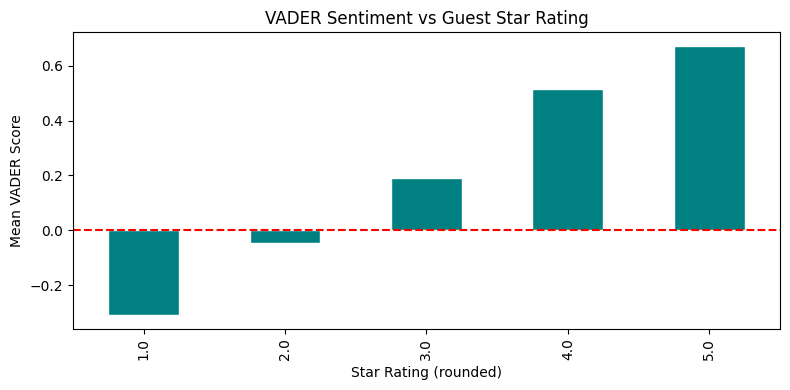

In [3]:
grouped = df.groupby(df['rating'].round(0))['vader_score'].mean()
grouped.plot(kind='bar', figsize=(8, 4), color='teal', edgecolor='white')
plt.xlabel('Star Rating (rounded)')
plt.ylabel('Mean VADER Score')
plt.title('VADER Sentiment vs Guest Star Rating')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## 3. Label distribution pie chart

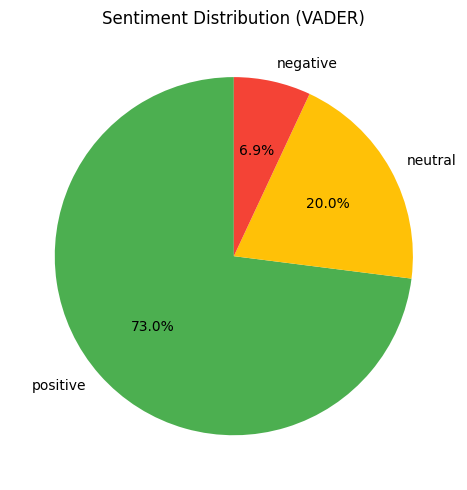

In [4]:
counts = df['vader_label'].value_counts()
colours = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=counts.index, colors=[colours[l] for l in counts.index],
        autopct='%1.1f%%', startangle=90)
plt.title('Sentiment Distribution (VADER)')
plt.tight_layout()
plt.show()

## 4. Accuracy vs star-derived ground truth

In [5]:
from sklearn.metrics import accuracy_score, classification_report

def star_to_label(r):
    if r >= 3.5: return 'positive'
    if r < 2.5:  return 'negative'
    return 'neutral'

df['true_label'] = df['rating'].apply(star_to_label)
acc = accuracy_score(df['true_label'], df['vader_label'])
print(f'VADER accuracy (vs star label): {acc:.3f}')
print()
print(classification_report(df['true_label'], df['vader_label']))

VADER accuracy (vs star label): 0.724

              precision    recall  f1-score   support

    negative       0.23      0.44      0.30        73
     neutral       0.23      0.34      0.27       265
    positive       0.91      0.80      0.85      1662

    accuracy                           0.72      2000
   macro avg       0.45      0.53      0.47      2000
weighted avg       0.79      0.72      0.75      2000



## 5. Sentiment by nationality (top 10 nationalities)

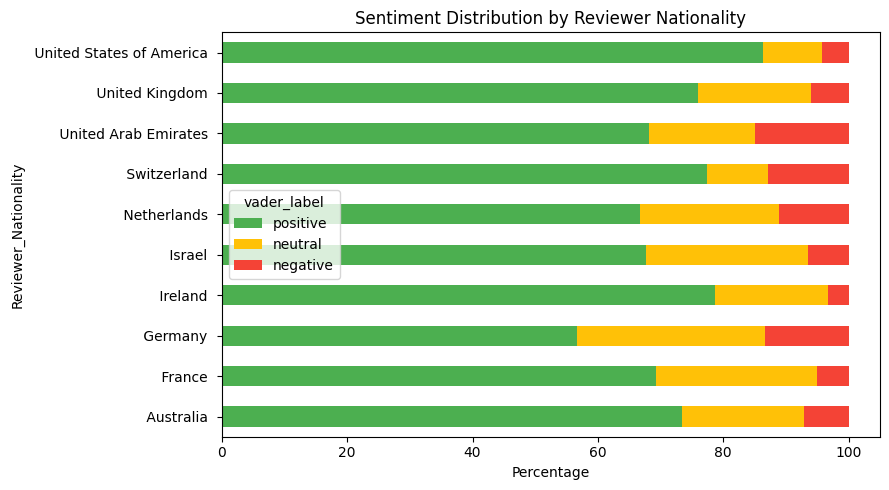

In [6]:
top_nat = df['Reviewer_Nationality'].value_counts().head(10).index
nat_df  = df[df['Reviewer_Nationality'].isin(top_nat)]
pivot   = nat_df.groupby(['Reviewer_Nationality', 'vader_label']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct[['positive', 'neutral', 'negative']].plot(
    kind='barh', stacked=True, figsize=(9, 5),
    color=['#4CAF50', '#FFC107', '#F44336']
)
plt.xlabel('Percentage')
plt.title('Sentiment Distribution by Reviewer Nationality')
plt.tight_layout()
plt.show()